In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
from os import environ
import os
import os

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixpoisson")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/wbic")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

dry = False # whether or not to save results

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/wbic


In [3]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [4]:
wbic_df = pd.read_csv(f"{outputdir}/wbic_bias.csv")
wbic_df.head()

,dsid,regime,n,trial,wbic,afe0,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,n_components
0,regular,50,50,0,148.380982,148.565676,1,1000,2500,0.0,0,0,[0],5,2
1,e-singular,50,50,0,139.051604,141.161511,1,1000,2500,0.0,0,0,[0],7,2
2,singular1,50,50,0,129.864095,128.380325,1,1000,2500,0.0,0,0,[0],8,2
3,singular2,50,50,0,112.492161,111.998226,1,1000,2500,0.0,0,0,[0],7,2
4,regular,50,50,0,149.435218,149.543682,1,1000,2500,0.0,0,0,[0],8,3


In [5]:
import numpy as np
# Prep data
wbic_df['error'] = wbic_df['wbic'] - wbic_df['afe0']
wbic_df['relative_error'] = wbic_df['error']/wbic_df['afe0']
wbic_df['Model'] = wbic_df['n_components'].map({2: 'K=2', 3: 'K=3', 5: 'K=5'})
wbic_df[["trial", "error", "relative_error"]]

,trial,error,relative_error
0,0,-0.184694,-0.001243
1,0,-2.109907,-0.014947
2,0,1.483769,0.011558
3,0,0.493936,0.004410
4,0,-0.108464,-0.000725
...,...,...,...
4711,130,0.934292,0.000085
4712,130,-3.528374,-0.000237
4713,130,-0.235945,-0.000018
4714,130,4.363900,0.000342


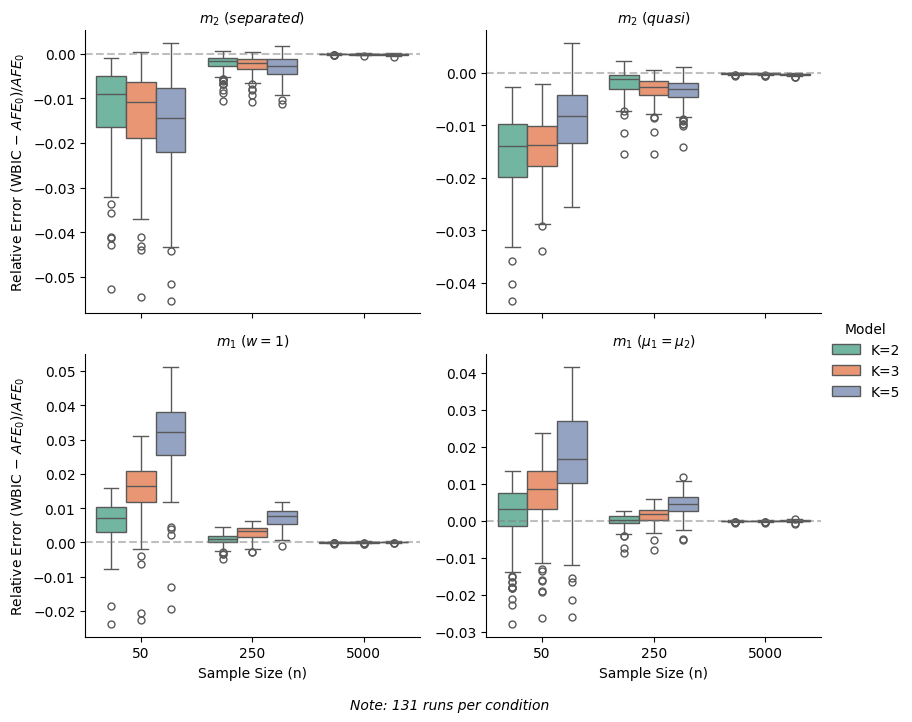

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create mapping with LaTeX
dsid_labels = {
  "regular": r"$m_2$ $(separated)$",
  "e-singular": r"$m_2$ $(quasi)$",
  "singular1": r"$m_1$ $(w=1)$",
  "singular2": r"$m_1$ $(\mu_1=\mu_2)$",
}

# Add display column
wbic_df["dgp_label"] = wbic_df["dsid"].map(dsid_labels)

# Box plot using catplot with shared y-axis
g = sns.catplot(
    data=wbic_df,
    x='n',
    y='relative_error',
    hue='Model',
    col='dgp_label',
    kind='box',
    col_wrap=2,
    sharey=False,
    height=3.5,
    aspect=1.2,
    palette='Set2'
)

# Add reference line at 0
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

g.set_axis_labels('Sample Size (n)', r'Relative Error (WBIC − $AFE_0$)/$AFE_0$')
g.set_titles(col_template='{col_name}')
# g.figure.suptitle('Relative WBIC Error Across Models (k=2,3,5) and Sample Sizes (n=50,250,5000)', fontsize=13, y=1.02)
g.figure.text(0.5, -0.02, f'Note: {len(wbic_df["trial"].unique())} runs per condition', 
              ha='center', fontsize=10, style='italic')
# plt.tight_layout()
plt.savefig(f'{outputdir}/wbic_bias_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

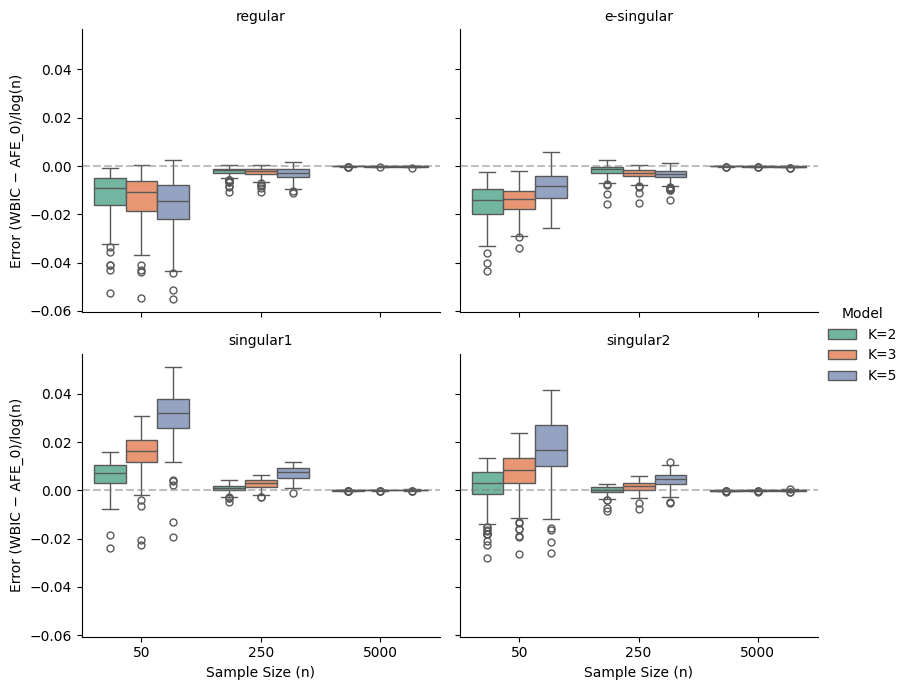

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot using catplot with shared y-axis
g = sns.catplot(
    data=wbic_df,
    x='n',
    y='relative_error',
    hue='Model',
    col='dsid',
    kind='box',
    col_wrap=2,
    sharey=True,
    height=3.5,
    aspect=1.2,
    palette='Set2'
)

# Add reference line at 0
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

g.set_axis_labels('Sample Size (n)', 'Error (WBIC − AFE_0)/log(n)')
g.set_titles(col_template='{col_name}')

# plt.tight_layout()
# plt.savefig('wbic_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Estimated convergence rates (RMSE ~ n^(-α)):
      dsid Model     alpha  intercept  r_squared
e-singular   K=2  0.042854   1.021044   0.939822
e-singular   K=3 -0.033070   0.728083   0.507842
e-singular   K=5 -0.189084  -0.148253   0.898630
   regular   K=2  0.030649   0.957451   0.923883
   regular   K=3  0.010346   0.993622   0.679171
   regular   K=5  0.005493   1.136368   0.807786
 singular1   K=2  0.007180   0.133252   0.978067
 singular1   K=3  0.084174   1.172592   0.893939
 singular1   K=5  0.101596   1.963914   0.689529
 singular2   K=2 -0.073844  -0.361347   0.964214
 singular2   K=3 -0.047284   0.124814   0.962329
 singular2   K=5  0.009256   0.999641   0.024319


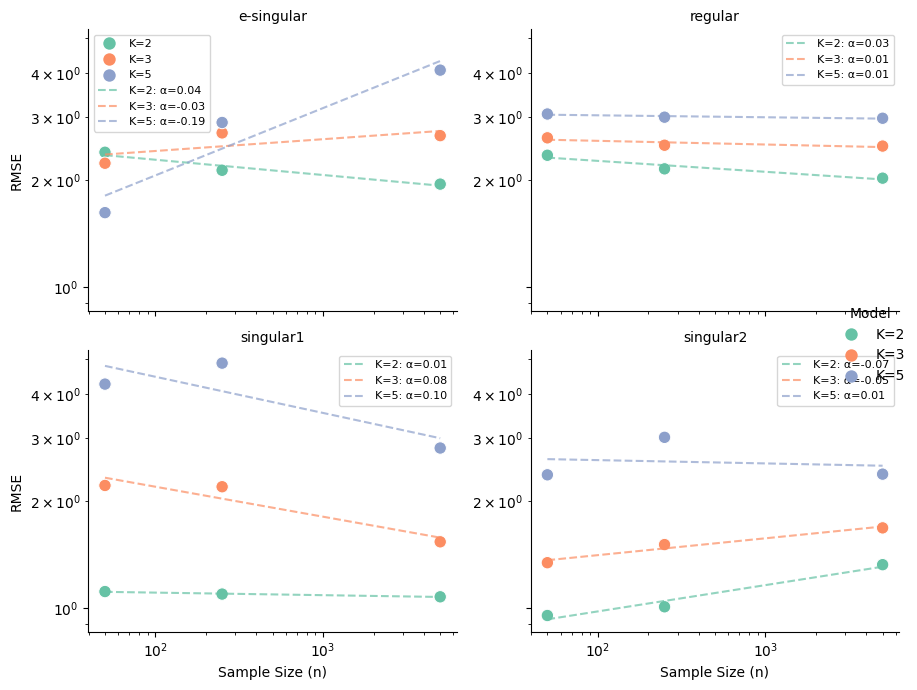


Convergence rates summary:
Model         K=2    K=3    K=5
dsid                           
e-singular  0.043 -0.033 -0.189
regular     0.031  0.010  0.005
singular1   0.007  0.084  0.102
singular2  -0.074 -0.047  0.009


In [9]:
from scipy import stats

# Aggregate: RMSE per (dsid, n, model)
summary = wbic_df.groupby(['dsid', 'n', 'Model']).agg(
    rmse=('error', lambda x: np.sqrt(np.mean(x**2)))
).reset_index()

# Log transform for regression
summary['log_n'] = np.log(summary['n'])
summary['log_rmse'] = np.log(summary['rmse'])

# Fit convergence rate for each (dsid, Model)
def fit_rate(group):
    slope, intercept, r, p, se = stats.linregress(group['log_n'], group['log_rmse'])
    return pd.Series({
        'alpha': -slope,
        'intercept': intercept,
        'r_squared': r**2
    })

rates = summary.groupby(['dsid', 'Model']).apply(fit_rate).reset_index()
print("Estimated convergence rates (RMSE ~ n^(-α)):")
print(rates.to_string(index=False))

# Plot using relplot (continuous x-axis)
g = sns.relplot(
    data=summary,
    x='n',
    y='rmse',
    hue='Model',
    col='dsid',
    kind='scatter',
    col_wrap=2,
    height=3.5,
    aspect=1.2,
    palette='Set2',
    s=80
)

# Add fitted convergence lines
for ax, dsid in zip(g.axes.flat, summary['dsid'].unique()):
    subset = summary[summary['dsid'] == dsid]
    n_vals = sorted(subset['n'].unique())
    n_range = np.linspace(min(n_vals), max(n_vals), 100)
    
    for model, color in zip(['K=2', 'K=3', 'K=5'], sns.color_palette('Set2')):
        rate_row = rates[(rates['dsid'] == dsid) & (rates['Model'] == model)]
        if len(rate_row) == 0:
            continue
        alpha = rate_row['alpha'].values[0]
        intercept = rate_row['intercept'].values[0]
        
        fitted = np.exp(intercept) * n_range ** (-alpha)
        ax.plot(n_range, fitted, color=color, linestyle='--', alpha=0.7,
                label=f'{model}: α={alpha:.2f}')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

g.set_axis_labels('Sample Size (n)', 'RMSE')
g.set_titles(col_template='{col_name}')

plt.tight_layout()
plt.show()

print("\nConvergence rates summary:")
pivot = rates.pivot(index='dsid', columns='Model', values='alpha')
print(pivot.round(3))